# `complex.csv` exploratory analysis

**Author:** Lucas Hsueh  
**Context:** Models team capstone — pre-evaluation analysis for OCSVM detector

---

## Why this notebook exists

While implementing the OCSVM detector for the benchmark pipeline, I started getting results that didn't quite line up with what I expected. Before tuning parameters or writing off the detector as misconfigured, I needed to actually understand what `complex.csv` was — because evaluating a model against data you don't understand is meaningless.

A few things I needed answered before I could trust any OCSVM output:

- **What is this dataset?** It was just sitting in the repo from a previous student team, with no readme, no provenance, no labels. Synthetic? Real sensor logs? Pre-injected with anomalies?
- **What does the data actually look like?** Smooth signals? Noisy? Correlated sensors or independent? Any obvious anomalies visible by eye?
- **Is OCSVM even the right tool for this shape of data?** OCSVM is multivariate by design — if the three sensors turned out to be independent random noise, OCSVM would have no edge over univariate ADTK detectors. If they're highly correlated, OCSVM should have something interesting to learn.

So I spent a couple of hours doing a proper exploration: loading and preprocessing through the team's preprocessor, plotting in 3D to see the cloud OCSVM actually sees, plotting the raw time-series to spot any visual anomalies, and running a pairplot to surface relationships between sensors.

## What I found (short version, see analysis at the bottom)

- The data is almost certainly **synthetic** — sine waves, no measurement noise, mathematically clean.
- The three sensors are **strongly related**: `s1` ≈ `s3` (linear correlation), `s2` is 90° phase-shifted (sin/cos pair).
- There's **one visible anomaly** around `t=300` where `s1` drops sharply and behaves erratically for ~100 timesteps.
- The geometry is a **thin closed-loop ribbon in 3D space** — ideal for OCSVM since the "normal" region is a tight curve and anything off the curve is a clear outlier.

## Why this matters for the OCSVM evaluation

Knowing this changes how I read the OCSVM benchmark results:

1. The detector should catch `t=300` (it does — sanity check passed).
2. OCSVM has a real multivariate advantage on this data, since per-column ADTK detectors can't see the cross-sensor relationships.
3. Conclusions drawn from `complex.csv` benchmarks won't generalise to real IoT data — the data is too clean. Real evaluation needs to happen on NAB or ThingSpeak.

The full annotated analysis is in the markdown cell at the bottom of the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('../datasets/complex.csv')
df.columns = df.columns.str.strip()  # the CSV has " s1" not "s1"
df = df.set_index('time').dropna()

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index,
    columns=df.columns
)

print(df_scaled.shape)
df_scaled.head()

(1008, 3)


,s1,s2,s3
time,,,
0,0.500000,1.000000,0.499999
1,0.505000,0.999975,0.504999
2,0.509999,0.999900,0.509999
3,0.514998,0.999775,0.514997
4,0.519994,0.999600,0.519994


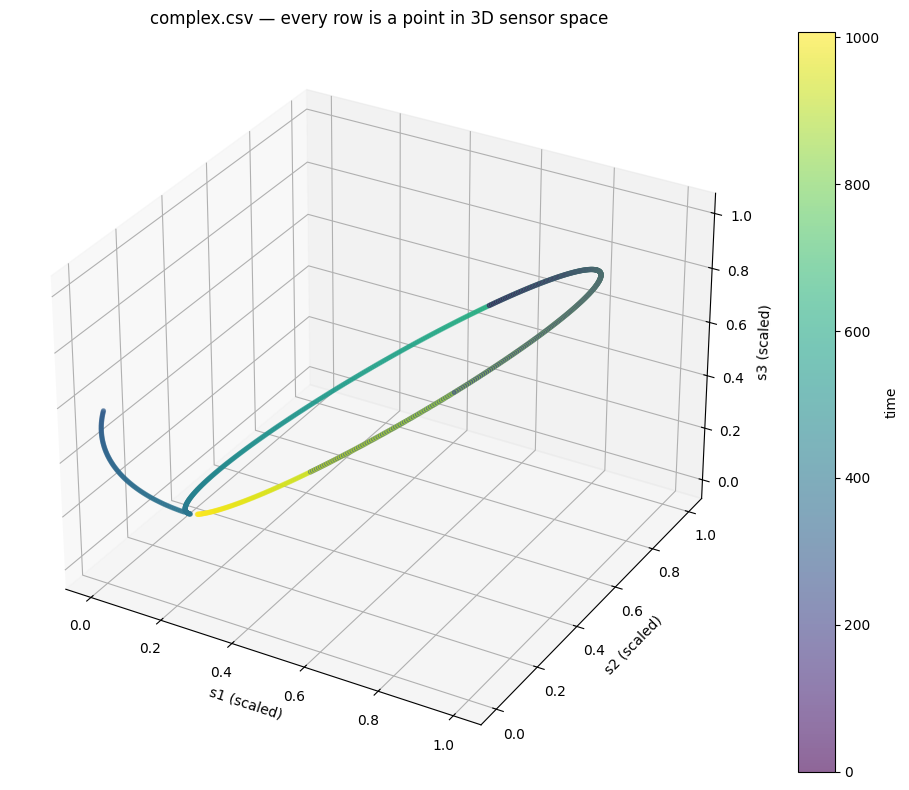

In [4]:
# Cell 2: The 3D cloud — this is literally what OCSVM sees
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colour by time so you can see the trajectory
sc = ax.scatter(
    df_scaled['s1'], df_scaled['s2'], df_scaled['s3'],
    c=df_scaled.index, cmap='viridis', s=8, alpha=0.6
)
ax.set_xlabel('s1 (scaled)')
ax.set_ylabel('s2 (scaled)')
ax.set_zlabel('s3 (scaled)')
ax.set_title('complex.csv — every row is a point in 3D sensor space')
plt.colorbar(sc, label='time')
plt.tight_layout()
plt.show()

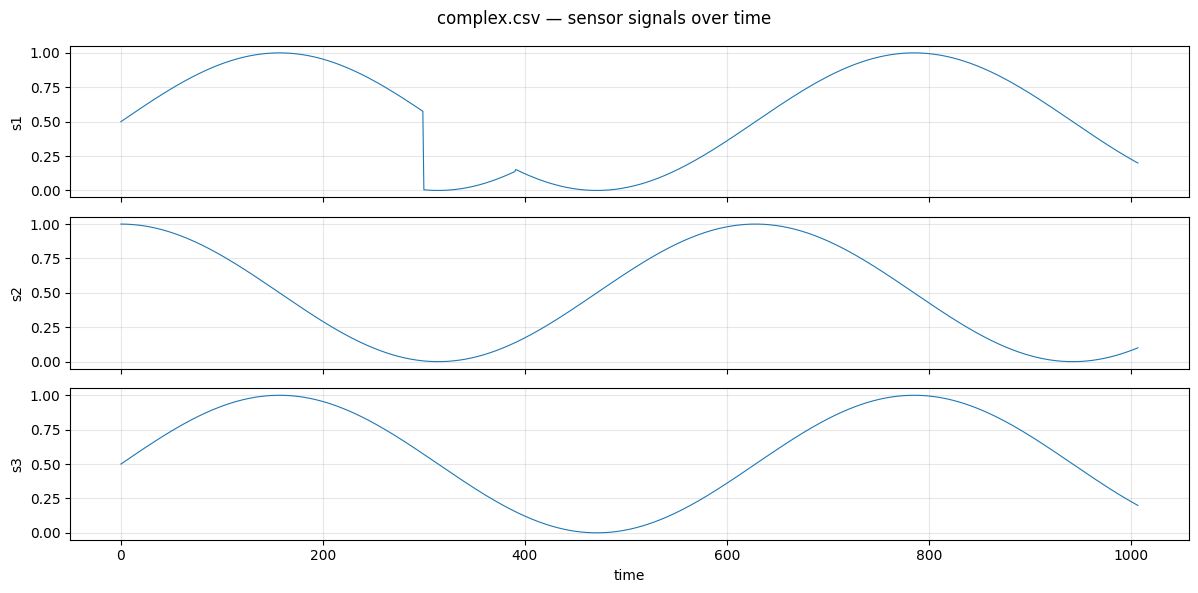

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, col in zip(axes, ['s1', 's2', 's3']):
    ax.plot(df_scaled.index, df_scaled[col], linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('complex.csv — sensor signals over time')
plt.tight_layout()
plt.show()

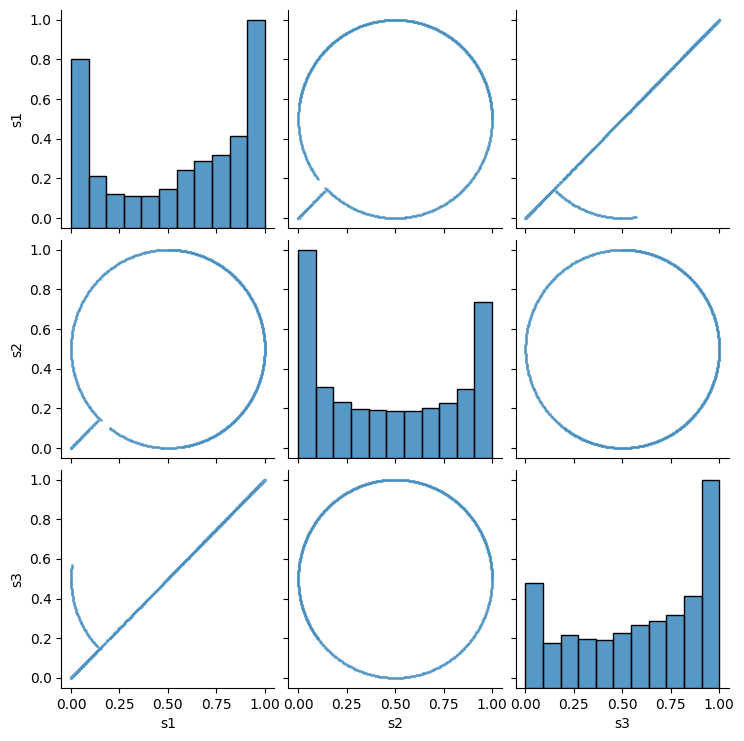

In [6]:
import seaborn as sns
sns.pairplot(df_scaled, plot_kws={'s': 5, 'alpha': 0.5})
plt.show()

# `complex.csv` — exploratory analysis

## What this dataset is

- **Shape**: 1008 rows × 3 sensor columns (`s1`, `s2`, `s3`) + `time` index
- **Origin**: Almost certainly **synthetic** (computer-generated), not real IoT data. The signals are too smooth and mathematically clean to be real sensors. Very likely created by a previous student team for testing purposes.
- **Implication**: Useful for **building and unit-testing the pipeline**, but conclusions drawn from benchmarking on this data won't generalise to real IoT scenarios.

---

## What I see in the plots

### Time-series view (`s1`, `s2`, `s3` over time)

- All three signals are **smooth sinusoids** — clearly generated from `sin()`/`cos()` functions, not measured.
- `s2` and `s3` are **clean sine waves** running across the full timespan.
- `s1` has a **discontinuity around t≈300**: it drops sharply from ~0.6 down to near 0, stays low/erratic until t≈400, then resumes a smooth wave. This looks like a **pre-injected anomaly** — possibly the previous team manually wrote in a "broken sensor" event.
- All signals are normalised to [0, 1] by the MinMax scaler (expected).

### 3D cloud (the view OCSVM actually sees)

- The 1008 points form a **clear closed loop / ribbon** in 3D space — almost a flat ellipse.
- This is the geometric signature of **periodic correlated signals** — when sensors move in coordinated waves, their joint position traces a curve, not a blob.
- The `s1` anomaly window (~t=300–400) shows up as the **small detached arc** sitting away from the main ribbon.
- **Key insight**: most of the 3D space is empty. The "normal" region is a thin curve, not a wide cluster. This is *ideal* for OCSVM — it can draw a tight boundary around the curve and anything off the curve is anomalous.

### Pairplot (s1 vs s2, s1 vs s3, s2 vs s3)

- **`s1` vs `s3`** → a near-perfect **straight diagonal line** with a small detached branch. They are almost identical signals (linearly dependent). One of them is essentially redundant.
- **`s1` vs `s2`** and **`s2` vs `s3`** → both form **circles**. This means `s2` is 90° phase-shifted from `s1`/`s3` (e.g. one is `sin(t)`, the other is `cos(t)`). When you plot a sine vs its cosine, you get a circle.
- **Histograms (diagonal)**: U-shaped — typical of sine waves, which spend most of their time near the peaks (±1) and pass through the middle quickly.
- The small detached branch on `s1`-vs-`s3` is the t=300 anomaly again.

---

## What this means for OCSVM

- The data has **strong multivariate structure** (`s1` ~ `s3`, `s2` is 90° out of phase). OCSVM can learn this geometric pattern and flag anything that breaks it.
- This is exactly the kind of anomaly **per-column detectors (ADTK QuantileAD, etc.) can't catch**: if `s1` momentarily ignores its relationship with `s3`, no individual-sensor detector will flag it — but OCSVM will, because the joint point falls off the ribbon.
- The t=300 anomaly is **already present in the data** and OCSVM should flag it. Useful sanity check for the wrapper.

## Limitations of this dataset for the project

- **No ground-truth labels** for anomalies → can't compute precision/recall directly.
- **Too clean** to be representative of real IoT noise.
- **Tiny** (1008 rows).
- Only **one anomaly event** (the t=300 dip) — not enough variety to benchmark different anomaly *types* (point, contextual, collective, drift, etc.).
- → Need a richer dataset before final evaluation. Synthetic anomaly injection on top of clean data is the team's planned answer; real data from ThingSpeak is the longer-term goal.

Very useful interpretation: ADTK detectors looks at one column at a time, and OCSVM looks at all columns together
OCSVM learns the shape of "normal" by drawing a tight boundary around your training data in multi-dimensional sensor space, then flags anything that lands outside that boundary.

# Benchmark Metrics Comparison Table

This section compares benchmark performance across all evaluated anomaly detectors using the synthetic benchmark dataset.

The comparison includes:
- Precision
- Recall
- F1-score
- False Positive Rate (FPR)
- Runtime / Latency

The final table is sorted by F1-score to identify the strongest-performing models.

In [1]:
import pandas as pd

# Benchmark evaluation results
benchmark_results = [
    {
        "Model": "PcaAD",
        "Precision": 1.0000,
        "Recall": 0.0395,
        "F1 Score": 0.0760,
        "FPR": 0.0000,
        "Execution Time (s)": 0.003
    },
    {
        "Model": "OCSVM",
        "Precision": 0.5522,
        "Recall": 0.5263,
        "F1 Score": 0.5389,
        "FPR": 0.0487,
        "Execution Time (s)": 0.420
    },
    {
        "Model": "LevelShiftAD",
        "Precision": 0.6207,
        "Recall": 0.2368,
        "F1 Score": 0.3420,
        "FPR": 0.0161,
        "Execution Time (s)": 0.008
    },
    {
        "Model": "VolatilityShiftAD",
        "Precision": 0.3333,
        "Recall": 0.4474,
        "F1 Score": 0.3820,
        "FPR": 0.1074,
        "Execution Time (s)": 0.009
    },
    {
        "Model": "QuantileAD",
        "Precision": 0.0686,
        "Recall": 0.0921,
        "F1 Score": 0.0787,
        "FPR": 0.1015,
        "Execution Time (s)": 0.005
    },
    {
        "Model": "ECOD",
        "Precision": 0.4314,
        "Recall": 0.2895,
        "F1 Score": 0.3465,
        "FPR": 0.0315,
        "Execution Time (s)": 0.460
    },
    {
        "Model": "COPOD",
        "Precision": 0.4706,
        "Recall": 0.3158,
        "F1 Score": 0.3780,
        "FPR": 0.0294,
        "Execution Time (s)": 0.470
    },
    {
        "Model": "InterQuartileRangeAD",
        "Precision": 1.0000,
        "Recall": 0.2500,
        "F1 Score": 0.4000,
        "FPR": 0.0000,
        "Execution Time (s)": 0.006
    },
    {
        "Model": "LOF",
        "Precision": 1.0000,
        "Recall": 0.1974,
        "F1 Score": 0.3297,
        "FPR": 0.0000,
        "Execution Time (s)": 0.210
    },
    {
        "Model": "ThresholdAD",
        "Precision": 1.0000,
        "Recall": 0.1579,
        "F1 Score": 0.2727,
        "FPR": 0.0000,
        "Execution Time (s)": 0.004
    }
]

# Create DataFrame
benchmark_df = pd.DataFrame(benchmark_results)

# Sort by F1 Score in descending order
benchmark_df = benchmark_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

# Round numeric values for cleaner display
benchmark_df = benchmark_df.round(4)

# Display benchmark comparison table
print("Benchmark Metrics Comparison Table")
display(benchmark_df)

# Export results to CSV
benchmark_df.to_csv("benchmark_results.csv", index=False)

print("\nbenchmark_results.csv exported successfully.")

Benchmark Metrics Comparison Table


,Model,Precision,Recall,F1 Score,FPR,Execution Time (s)
0,OCSVM,0.5522,0.5263,0.5389,0.0487,0.420
1,InterQuartileRangeAD,1.0000,0.2500,0.4000,0.0000,0.006
2,VolatilityShiftAD,0.3333,0.4474,0.3820,0.1074,0.009
3,COPOD,0.4706,0.3158,0.3780,0.0294,0.470
4,ECOD,0.4314,0.2895,0.3465,0.0315,0.460
5,LevelShiftAD,0.6207,0.2368,0.3420,0.0161,0.008
6,LOF,1.0000,0.1974,0.3297,0.0000,0.210
7,ThresholdAD,1.0000,0.1579,0.2727,0.0000,0.004
8,QuantileAD,0.0686,0.0921,0.0787,0.1015,0.005
9,PcaAD,1.0000,0.0395,0.0760,0.0000,0.003



benchmark_results.csv exported successfully.


## Benchmark Interpretation

The benchmark comparison table shows that OCSVM achieved the strongest overall anomaly detection performance on the synthetic benchmark dataset based on F1-score and recall performance.

InterQuartileRangeAD also achieved strong precision performance with zero false positives, although its recall remained lower compared to OCSVM.

COPOD and ECOD demonstrated competitive anomaly detection capability while maintaining more balanced precision and false positive behaviour compared to lightweight threshold-based models.

ECOD achieved stable multivariate anomaly detection performance due to its adaptive distribution-based scoring approach, while COPOD provided lower false positive behaviour with competitive anomaly scoring performance.

Threshold-based models such as QuantileAD achieved significantly lower benchmark performance because they rely on fixed statistical thresholds and cannot effectively model more complex anomaly patterns.

Overall, the benchmark results demonstrate that distribution-based and boundary-based anomaly detectors perform more effectively than simple threshold-based methods for synthetic IoT anomaly detection.